In [20]:
import cv2
from yunet import YuNet


def draw_faces(
    image: cv2.typing.MatLike,
    faces: list[list[float]],
    color: tuple[int, int, int] = (0, 255, 0),
):
    drawed_image = image.copy()
    for face in faces:
        x, y, w, h = face[:4]
        cv2.rectangle(
            drawed_image, (int(x), int(y)), (int(x + w), int(y + h)), color, 2
        )
        for i in range(4, 14, 2):
            cv2.circle(drawed_image, (int(face[i]), int(face[i + 1])), 2, color, 2)
    return drawed_image


def detect_single_face_multiscale(
    image: cv2.typing.MatLike, model: YuNet, scale_factor: float = 1.1
):
    org_h, org_w = image.shape[:2]

    scale = 1.0
    while min(scale * org_h, scale * org_w) >= 50:
        h, w = int(scale * org_h), int(scale * org_w)
        scaled_image = cv2.resize(image, (w, h))

        model.setInputSize((w, h))
        faces = model.infer(scaled_image)

        if len(faces) >= 2:
            return None, None

        if len(faces) == 1:
            return (faces[0], scale)

        scale /= scale_factor

    return None, None

In [25]:
import os, cv2
from matplotlib import pyplot as plt
import numpy as np
from tqdm import tqdm
from yunet import YuNet
from sface import SFace


CARDS_DIR = "datasets/cards"
SELFIES_DIR = "datasets/selfies_20241030"

detector = YuNet(
    modelPath="weights/face_detection_yunet_2023mar.onnx", confThreshold=0.8
)
embedder = SFace(modelPath="weights/face_recognition_sface_2021dec.onnx")

cards_name = os.listdir(CARDS_DIR)
selfies_name = os.listdir(SELFIES_DIR)

for card_name in tqdm(cards_name):
    card_path = os.path.join(CARDS_DIR, card_name)
    student_id = card_name.split("_")[0]

    # Find selfies of student
    selfies_of_student = list(filter(lambda x: student_id in x, selfies_name))
    if len(selfies_of_student) == 0:
        continue
    selfies_of_student = selfies_of_student[0]
    selfies_of_student_path = os.path.join(SELFIES_DIR, selfies_of_student)

    # Detect face in card
    card_image = cv2.imread(card_path)
    face_in_card, scale = detect_single_face_multiscale(card_image, detector)
    if face_in_card is None:
        print(f"Cannot detect face in card {card_name}")
        continue
    scaled_card_image = cv2.resize(
        card_image, (int(scale * card_image.shape[1]), int(scale * card_image.shape[0]))
    )

    for selfie_name in os.listdir(selfies_of_student_path):
        selfie_image = cv2.imread(os.path.join(selfies_of_student_path, selfie_name))

        face_in_selfie, scale2 = detect_single_face_multiscale(selfie_image, detector)
        if face_in_selfie is None:
            print(f"Cannot detect face in selfie {selfie_name}")
            continue
        scaled_selfie_image = cv2.resize(
            selfie_image,
            (int(scale2 * selfie_image.shape[1]), int(scale2 * selfie_image.shape[0])),
        )

        distance, is_match = embedder.match(
            scaled_card_image, face_in_card, scaled_selfie_image, face_in_selfie
        )

        drawed_card = None
        drawed_selfie = None

        if is_match:
            drawed_card = draw_faces(scaled_card_image, [face_in_card])
            drawed_selfie = draw_faces(scaled_selfie_image, [face_in_selfie])
            drawed_selfie = cv2.putText(
                drawed_selfie,
                f"Distance: {distance:.2f}",
                (10, 20),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                1,
                cv2.LINE_AA,
            )
        else:
            drawed_card = draw_faces(scaled_card_image, [face_in_card], (0, 0, 255))
            drawed_selfie = draw_faces(
                scaled_selfie_image, [face_in_selfie], (0, 0, 255)
            )
            drawed_selfie = cv2.putText(
                drawed_selfie,
                f"Distance: {distance:.2f}",
                (10, 20),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 0, 255),
                1,
                cv2.LINE_AA,
            )

        h1, w1 = drawed_card.shape[:2]
        h2, w2 = drawed_selfie.shape[:2]
        vis = np.zeros((max(h1, h2), w1 + w2, 3), np.uint8)
        vis[:h1, :w1, :3] = drawed_card
        vis[:h2, w1 : w1 + w2, :3] = drawed_selfie
        os.makedirs(f"results/yunet-sface/{student_id}", exist_ok=True)
        cv2.imwrite(f"results/yunet-sface/{student_id}/{selfie_name}", vis)

  0%|          | 0/314 [00:00<?, ?it/s]

Cannot detect face in selfie vlcsnap-00031.png


100%|██████████| 314/314 [00:25<00:00, 12.55it/s]


In [13]:
# import cv2


# def draw_face(image: cv2.typing.MatLike, faces):
#     copy_image = image.copy()
#     for face in faces:
#         x, y, w, h = map(int, face[:4])
#         cv2.rectangle(copy_image, (x, y), (x + w, y + h), (255, 0, 0), 2)
#     return copy_image

In [27]:
# import os, cv2
# from tqdm import tqdm
# from yunet import YuNet

# faces_in_cards = []
# cards_path = []
# cards_image = []

# face_detector = YuNet(
#     modelPath="weights/face_detection_yunet_2023mar.onnx", confThreshold=0.75
# )

# for CARDS_DIR in ["datasets/cards/TheThuVien", "datasets/cards/TheSinhVien"]:
#     cards_name = os.listdir(CARDS_DIR)

#     for card_name in tqdm(cards_name):
#         card_path = os.path.join(CARDS_DIR, card_name)
#         card_image = cv2.imread(card_path)

#         cards_path.append(card_path)
#         cards_image.append(card_image)

#         card_h, card_w = card_image.shape[:2]
#         face_detector.setInputSize((card_w, card_h))
#         face_in_card = face_detector.infer(card_image)

#         faces_in_cards.append(face_in_card)

100%|██████████| 64/64 [00:15<00:00,  4.04it/s]


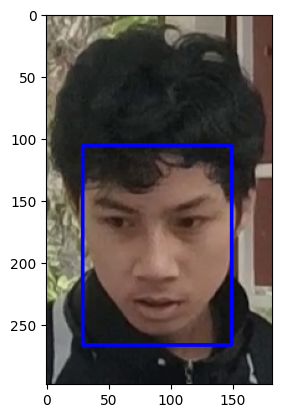

100%|██████████| 313/313 [00:05<00:00, 55.45it/s]


('datasets/cards/TheSinhVien/23T1020385.jpg', 0.4162167952499658)


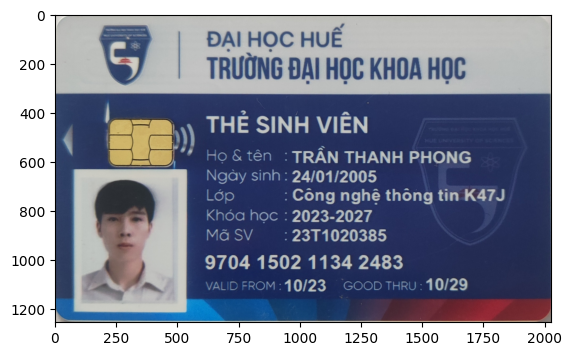

('datasets/cards/TheThuVien/24T1020089.jpg', 0.41466173284092633)


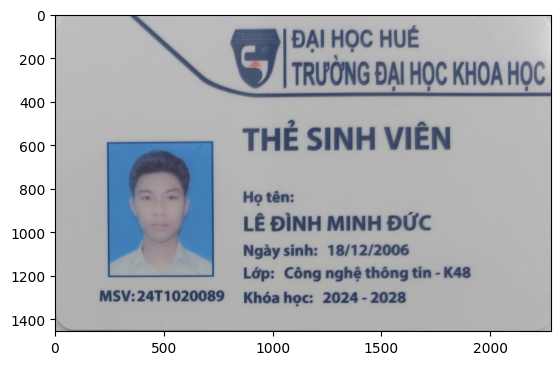

In [44]:
# import cv2
# from tqdm import tqdm
# from yunet import YuNet
# from sface import SFace
# from matplotlib import pyplot as plt

# image_path = "datasets/selfies/vlcsnap-2025-01-21-21h02m40s548.png"
# image = cv2.imread(image_path)
# h, w = image.shape[:2]

# face_detector = YuNet(
#     modelPath="weights/face_detection_yunet_2023mar.onnx", confThreshold=0.75
# )
# face_detector.setInputSize((w, h))
# faces = face_detector.infer(image)

# if len(faces) == 0:
#     print("No face detected")
#     exit()

# drawed_image = draw_face(image, faces)
# plt.imshow(cv2.cvtColor(drawed_image, cv2.COLOR_BGR2RGB))
# plt.show()

# face_recognize = SFace(modelPath="weights/face_recognition_sface_2021dec.onnx")

# results = []
# for idx, card_path in enumerate(tqdm(cards_path)):
#     if len(faces_in_cards[idx]) == 0:
#         continue

#     distance, is_match = face_recognize.match(
#         image, faces[0], cards_image[idx], faces_in_cards[idx][0]
#     )
#     if is_match:
#         results.append((card_path, distance))

# results = sorted(results, key=lambda x: -1 * x[1])

# if len(results) == 0:
#     print("No match found")
# else:
#     for result in results:
#         tmp_image = cv2.imread(result[0])
#         print(result)
#         plt.imshow(cv2.cvtColor(tmp_image, cv2.COLOR_BGR2RGB))
#         plt.show()